In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
data = {
    "review": [
        "Excellent product, good quality and fast delivery",
        "The product works exactly as described",
        "Good quality for the price",
        "Arrived on time and packaging was neat",
        "I have been using this for two weeks and it works well",
        "The material feels strong and useful",
        "Decent product and reasonable quality",
        "Battery lasts long and performance is good",
        "The size was accurate and fits perfectly",
        "Quality is acceptable and delivery was quick",

        "BEST PRODUCT EVER BUY NOW 100% AMAZING",
        "Five stars this is the greatest product in the world",
        "Amazing amazing amazing everyone must buy this",
        "Perfect product perfect seller perfect delivery",
        "Unbelievable quality I love everything about this",
        "Buy this now you will never find anything better",
        "This product changed my life completely absolutely flawless",
        "Wonderful fantastic excellent highly recommended",
        "100% genuine and 100% perfect just buy it",
        "The best purchase ever five stars are not enough"
    ],

    "label": [
        "genuine", "genuine", "genuine", "genuine", "genuine",
        "genuine", "genuine", "genuine", "genuine", "genuine",
        "fake", "fake", "fake", "fake", "fake",
        "fake", "fake", "fake", "fake", "fake"
    ]
}

df = pd.DataFrame(data)

print(df)
print("\nDataset Shape:", df.shape)

                                               review    label
0   Excellent product, good quality and fast delivery  genuine
1              The product works exactly as described  genuine
2                          Good quality for the price  genuine
3              Arrived on time and packaging was neat  genuine
4   I have been using this for two weeks and it wo...  genuine
5                The material feels strong and useful  genuine
6               Decent product and reasonable quality  genuine
7          Battery lasts long and performance is good  genuine
8            The size was accurate and fits perfectly  genuine
9        Quality is acceptable and delivery was quick  genuine
10             BEST PRODUCT EVER BUY NOW 100% AMAZING     fake
11  Five stars this is the greatest product in the...     fake
12     Amazing amazing amazing everyone must buy this     fake
13    Perfect product perfect seller perfect delivery     fake
14  Unbelievable quality I love everything about this  

label
genuine    10
fake       10
Name: count, dtype: int64


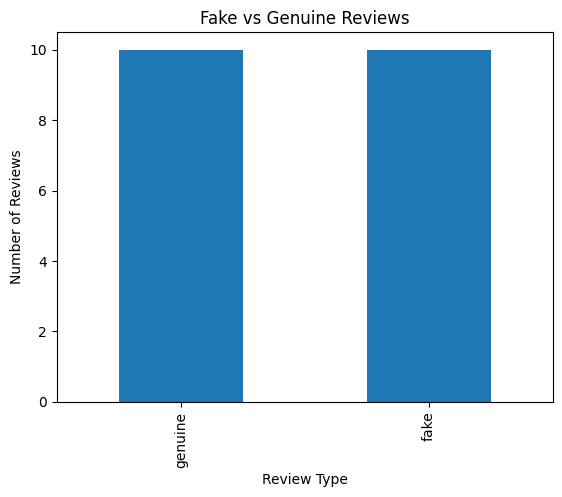

In [4]:
print(df["label"].value_counts())

df["label"].value_counts().plot(kind="bar")
plt.title("Fake vs Genuine Reviews")
plt.xlabel("Review Type")
plt.ylabel("Number of Reviews")
plt.show()

In [5]:
X = df["review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16
Testing samples: 4


In [6]:
vectorizer = TfidfVectorizer(stop_words="english")

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF conversion completed!")

TF-IDF conversion completed!


In [7]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [8]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 100.0 %


In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        fake       1.00      1.00      1.00         2
     genuine       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



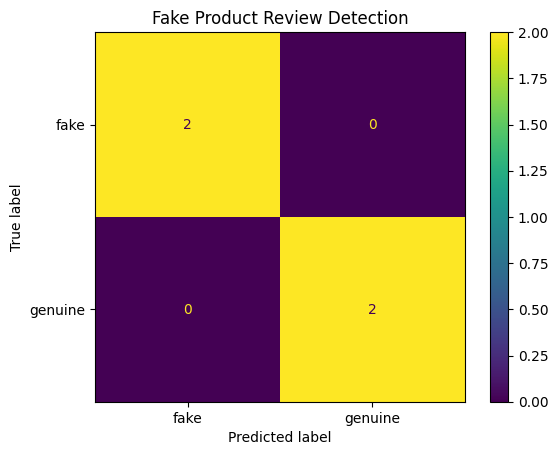

In [10]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Fake Product Review Detection")
plt.show()

In [11]:
review = ["The product quality is excellent and delivery was very fast"]

review_tfidf = vectorizer.transform(review)

prediction = model.predict(review_tfidf)

print("Review:", review[0])
print("Prediction:", prediction[0].upper())

Review: The product quality is excellent and delivery was very fast
Prediction: GENUINE
